# FlexTok: Resampling Images into 1D Token Sequences of Flexible Length

[`Website`](https://flextok.epfl.ch) | [`arXiv`](https://arxiv.org/abs/2502.13967) | [`GitHub`](https://github.com/apple/ml-flextok)

Official implementation for: <br>
[**FlexTok: Resampling Images into 1D Token Sequences of Flexible Length**](https://arxiv.org/abs/2502.13967), arXiv 2025 <br>
*[Roman Bachmann](https://roman-bachmann.github.io/)\*, [Jesse Allardice](https://github.com/JesseAllardice)\*, [David Mizrahi](https://dmizrahi.com/)\*, [Enrico Fini](https://scholar.google.com/citations?user=OQMtSKIAAAAJ), [Oğuzhan Fatih Kar](https://ofkar.github.io/), [Elmira Amirloo](https://elamirloo.github.io/), [Alaaeldin El-Nouby](https://aelnouby.github.io/), [Amir Zamir](https://vilab.epfl.ch/zamir/), [Afshin Dehghan](https://scholar.google.com/citations?user=wcX-UW4AAAAJ)*

FlexTok is a tokenizer that enables representing images as an ordered one-dimensional sequence of tokens. It consists of an ViT register encoder mapping images to token sequences, and a ViT register rectified flow decoder mapping token sequences back to images. The encoder and decoder operate on a VAE latent space, and this notebook contains both examples for FlexTok and VAE inference.

Please make sure to follow the installation instructions outlined in the official repository. We recommend running this notebook on A100s or H100s and to perform inference in `bfloat16`.

In [1]:
# Switch path to root of project
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '7'
current_folder = globals()['_dh'][0]
os.chdir(os.path.dirname(os.path.abspath(current_folder)))

%load_ext autoreload
%autoreload 2

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

import einops
import torch
import torchvision.transforms.functional as TF

from diffusers.models import AutoencoderKL

from flextok.flextok_wrapper import FlexTokFromHub
from flextok.utils.demo import imgs_from_urls, denormalize, batch_to_pil
from flextok.utils.misc import detect_bf16_support, get_bf16_context, get_generator

# The flag below controls whether to allow TF32 on matmul. This flag defaults to False in PyTorch 1.12 and later.
torch.backends.cuda.matmul.allow_tf32 = True
# The flag below controls whether to allow TF32 on cuDNN. This flag defaults to True.
torch.backends.cudnn.allow_tf32 = True

# Global no_grad
torch.set_grad_enabled(False)

# Automatically set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

# Detect if bf16 is enabled or not
enable_bf16 = detect_bf16_support()
print('BF16 enabled:', enable_bf16)

Device: cuda
BF16 enabled: True


/home/iyu/miniconda3/envs/flextok/lib/python3.10/site-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


## 1 Loading example images

We load several demo images to showcase FlexTok and VAE reconstructions for. Feel free to use your own images!

When working with ImageNet-style images, we recommend loading the dedicated ImageNet FlexTok models, while for all other cases we recommend the DFN version.

val dataset: 7999 images
Loaded images:


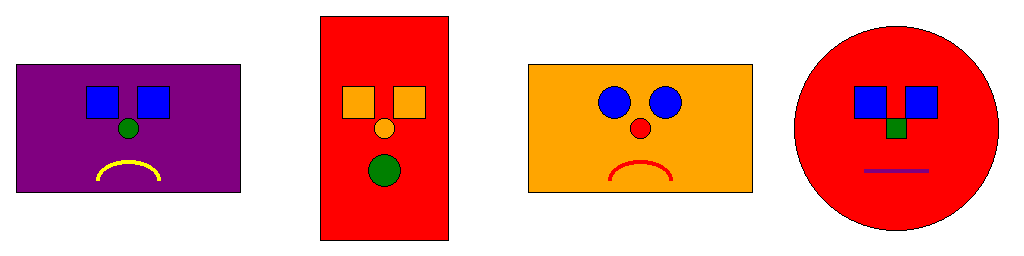

In [4]:
from flextok.utils.dataloader import SyntheticFaceDataset, create_celeb_dataloader, CelebADataset, CelebAHQDataset
from flextok.utils.demo import denormalize, batch_to_pil

# load dataset
IMG_SIZE = 256
BATCH_SIZE = 4
DATASET_PATH = "./data/synth_faces/"

# test dataset
val_dataset = SyntheticFaceDataset(
    root_dir=DATASET_PATH,
    img_size=IMG_SIZE,
    split="val",
)

print(f"val dataset: {len(val_dataset)} images")
# get images from val dataset
val_dataloader = create_celeb_dataloader(
    dataset_type="synth_faces",
    root_dir=DATASET_PATH,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=1,
)
# get a batch of images
imgs = next(iter(val_dataloader)).to(device)

# imgs = imgs_from_urls([
#     "https://cdn.mos.cms.futurecdn.net/fAmJwNKXnajJb4aZYyvfsH.jpg",
#     "https://wolflawpllc.com/wp-content/uploads/2023/11/crowd-surge-at-a-concert.png",
#     "https://www.album-online.com/photos/prev/Njc2NjE1MA/album_alb5538449.jpg",
#     "https://imagez.tmz.com/image/6d/4by3/2022/04/18/6dad5b56b281408abd8b4178786ea708_md.png"
# ]).to(device)
# apply flips to test robustness
print('Loaded images:')
batch_to_pil(imgs)

## 2 FlexTok inference

The FlexTok encoder maps an image into a one-dimensional sequence of 256 register tokens. These tokens are discretized using FSQ, resulting in a vocabulary of 64,000 tokens.

FlexTok was trained so that these quantized register tokens represent images in a hierarchical and ordered manner. Specifically, truncated subsequences of lengths _1, 2, 4, 8, 16, 32, 64, 128, and 256_ tokens all represent valid images, and as more tokens are used, the reconstructions increasingly resemble the encoded image. Although FlexTok was trained solely using a rectified flow and REPA objective, the truncated token sequences emerge as highly semantic compressions of the original image, capturing its most salient aspects with the fewest tokens.

To showcase this, we load here our largest FlexTok tokenizer (18 encoder layers, 28 decoder layers) trained on DFN. We load it directly from HuggingFace Hub. Please see the official repository for instructions on how to load models manually.

**Warning**: Executing the following cell will download a 10.2 GB model. This may take a while depending on your connection.

In [5]:
# Load a FlexTok d18-d28 model trained on DFN from HuggingFace Hub
flextok = FlexTokFromHub.from_pretrained('EPFL-VILAB/flextok_d18_d18_in1k').to(device).eval()

## 2.1.1 Load checkpoint (optional)
Load custom checkpoints here.

In [7]:
from flextok.regularizers.quantize_fsq import FSQ
from flextok.model.postprocessors.heads import LinearHead
from flextok.model.preprocessors.linear import LinearLayer

ckpt_path = "/home/iyu/ml-flextok/checkpoints/synth_d18_fsq_8/20251215/checkpoint_best.pt"
new_levels = [8]

if new_levels is not None:
    # Get the original FSQ configuration
    old_fsq: FSQ = flextok.regularizer

    # Check if the encoder output dimension matches the fsq levels length
    old_fsq_output_dim = old_fsq.dim
    if old_fsq_output_dim != len(new_levels):
        # project encoder dim to new fsq dim
        print(f"Adjusting encoder output dimension from {old_fsq_output_dim} to {len(new_levels)}")
        new_enc_linear_head = LinearHead(
            read_key=flextok.encoder.module_dict["enc_to_latents"].read_key,
            write_key=flextok.encoder.module_dict["enc_to_latents"].write_key,
            dim=flextok.encoder.module_dict["enc_to_latents"].dim_in,
            dim_out=len(new_levels),
            use_mup_readout=False,
        )

        flextok.encoder.module_dict['enc_to_latents'] = new_enc_linear_head

        # project back from fsq to decoder input dim
        print(f"Adjusting decoder input dimension to {len(new_levels)}")
        new_dec_linear_head = LinearLayer(
            read_key=flextok.decoder.module_dict["dec_from_latents"].read_key,
            write_key=flextok.decoder.module_dict["dec_from_latents"].write_key,
            dim_in=len(new_levels),
            dim=flextok.decoder.module_dict["dec_from_latents"].dim_out,
        )
        flextok.decoder.module_dict['dec_from_latents'] = new_dec_linear_head

    # Create new FSQ with modified levels
    new_fsq = FSQ(
        latents_read_key=old_fsq.latents_read_key,
        quants_write_key=old_fsq.quants_write_key,
        tokens_write_key=old_fsq.tokens_write_key,
        levels=new_levels,
        drop_quant_p=old_fsq.drop_quant_p,
        corrupt_tokens_p=old_fsq.corrupt_tokens_p,
        min_corrupt_tokens_p=old_fsq.min_corrupt_tokens_p,
        apply_corrupt_tokens_p=old_fsq.apply_corrupt_tokens_p,
        packed_call=old_fsq.packed_call,
    )

    # Replace the FSQ module
    flextok.regularizer = new_fsq
    
checkpoint = torch.load(ckpt_path, map_location='cuda', weights_only=False)
flextok.load_state_dict(checkpoint['model_state_dict'])
flextok = flextok.to(device).eval()

### 2.1 Autoencoding using all 256 tokens

First, a simple example of autoencoding images using FlexTok. We tokenize images into 256 tokens each using the FlexTok encoder. The first time this cell is run might take some time, but subsequent executions should be faster.

In [8]:
with get_bf16_context(enable_bf16):
    tokens_list = flextok.tokenize(imgs) # List of [1, 256] discrete token sequences

/home/iyu/ml-flextok/flextok/model/utils/posembs.py:124: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  posembs = posembs[slices]


Then , we detokenize all 256 register tokens back into images using the FlexTok rectified flow decoder. There are three important hyperparameters for the rectified flow decoder:

- `timesteps`: Number of denoising steps. 25 steps provides a good balance between reconstruction quality and inference speed.
- `guidance_scale`: Classifier-free guidance scale. See the paper appendix for guidance scale sweeps for all models. We recommend guidance scale 7.5, except for the FlexTok d12-d12 model where we recommend guidance scale 15.
- `perform_norm_guidance`: Whether or not to perform Adaptive Projected Guidance (APG), see https://arxiv.org/abs/2410.02416. We recommend setting this to True.

In [9]:
with get_bf16_context(enable_bf16):
    reconst = flextok.detokenize(
        tokens_list,
        timesteps=25, # Number of denoising steps
        guidance_scale=7.5, # Classifier-free guidance scale
        perform_norm_guidance=True, # APG, see https://arxiv.org/abs/2410.02416
         # Optionally control initial noise. Note that while the initial noise is deterministic, the rest of the model isn't.
        generator=get_generator(seed=0, device=device),
        verbose=False, # Enable to show denoising progress bar with tqdm
    )

/home/iyu/ml-flextok/flextok/model/utils/posembs.py:124: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  posembs = posembs[slices]
/home/iyu/ml-flextok/flextok/model/utils/posembs.py:124: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  posembs = posembs[slices]


Reconstructions using all 256 tokens:


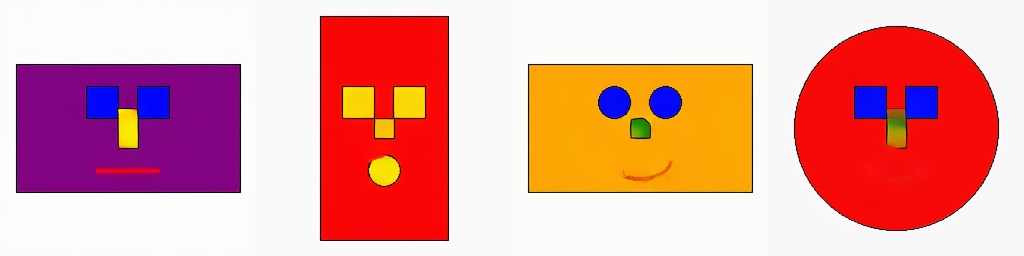

In [10]:
print('Reconstructions using all 256 tokens:')
batch_to_pil(reconst)

### 2.2 Flexible-length tokenization

Now we encode each image once and show reconstructions from the first _1, 2, 4, ..., 256_ tokens. Practically this means truncating the token sequences from the right, keeping only the chosen number of tokens, and running the rectified flow decoder on only that subset of tokens.

In [11]:
def plot_flexible_length_reconsts(imgs, k_keep_list, figscale=3.0, seed=None):
    # Tokenize images once
    with get_bf16_context(enable_bf16):
        tokens_list = flextok.tokenize(imgs) # List of [1, 256] discrete token sequences
        
    # Detokenize various subsequences
    all_reconst = {}
    for k_keep in k_keep_list:
        # Simply truncate the token sequences from the right
        subseq_list = [seq[:,:k_keep].clone() for seq in tokens_list]
        with get_bf16_context(enable_bf16):
            generator = get_generator(seed=seed, device=device)
            all_reconst[k_keep] = flextok.detokenize(
                subseq_list, timesteps=25, 
                guidance_scale=7.5, perform_norm_guidance=True,
                generator=generator, verbose=False,
            )
    
    # Plotting
    ncols = len(k_keep_list) + 1 # 1 | 2 | 4 | ... | 256 | GT
    nrows = imgs.shape[0]

    fig, axes = plt.subplots(nrows, ncols, figsize=(figscale*ncols, figscale*nrows))
    axes = [axes] if nrows == 1 else axes
    
    imgs_plot = denormalize(imgs)
    all_reconst = {k_keep: denormalize(rec).clamp(0,1) for k_keep, rec in all_reconst.items()}
    
    for img_idx in range(nrows):
        for col_idx, k_keep in enumerate(k_keep_list):
            axes[img_idx][col_idx].imshow(TF.to_pil_image(all_reconst[k_keep][img_idx]))
        axes[img_idx][-1].imshow(TF.to_pil_image(imgs_plot[img_idx]))
        
        for ax in axes[img_idx]:
            ax.axis("off")

    for col_idx, k_keep in enumerate(k_keep_list):
        title = f'{k_keep} token' + ('' if k_keep == 1 else 's')
        axes[0][col_idx].set_title(title, fontsize=18)
    axes[0][-1].set_title('Groundtruth', fontsize=18)

    plt.tight_layout()
    plt.show()

Below are the reconstructions from various subsequences. Even with a high degree of compression (each token can only be one of 64'000 classes, i.e. takes up 2 bytes), the reconstructions capture the most important high-level semantic and geometric information first. In the first example, with merely 4 tokens FlexTok captures the essence of a painted bird looking towards the right. 

Depending on the image complexity, different number of tokens are required to faithfully reconstruct the given images. For example, simple images that contain only one central object (like the apple) can be reconstructed well with as few as 1-16 tokens. By this we mean that the main concept, here "single apple in front of neutral background" is faithfully captured, while details like the length of the stem or texture on the fruit are abstracted away. On the other hand, more complex scenes like the image of a crowd of people requires 64-256 tokens to capture the position and clothing of each person, while the gist of the scene is captured by only 4 tokens.

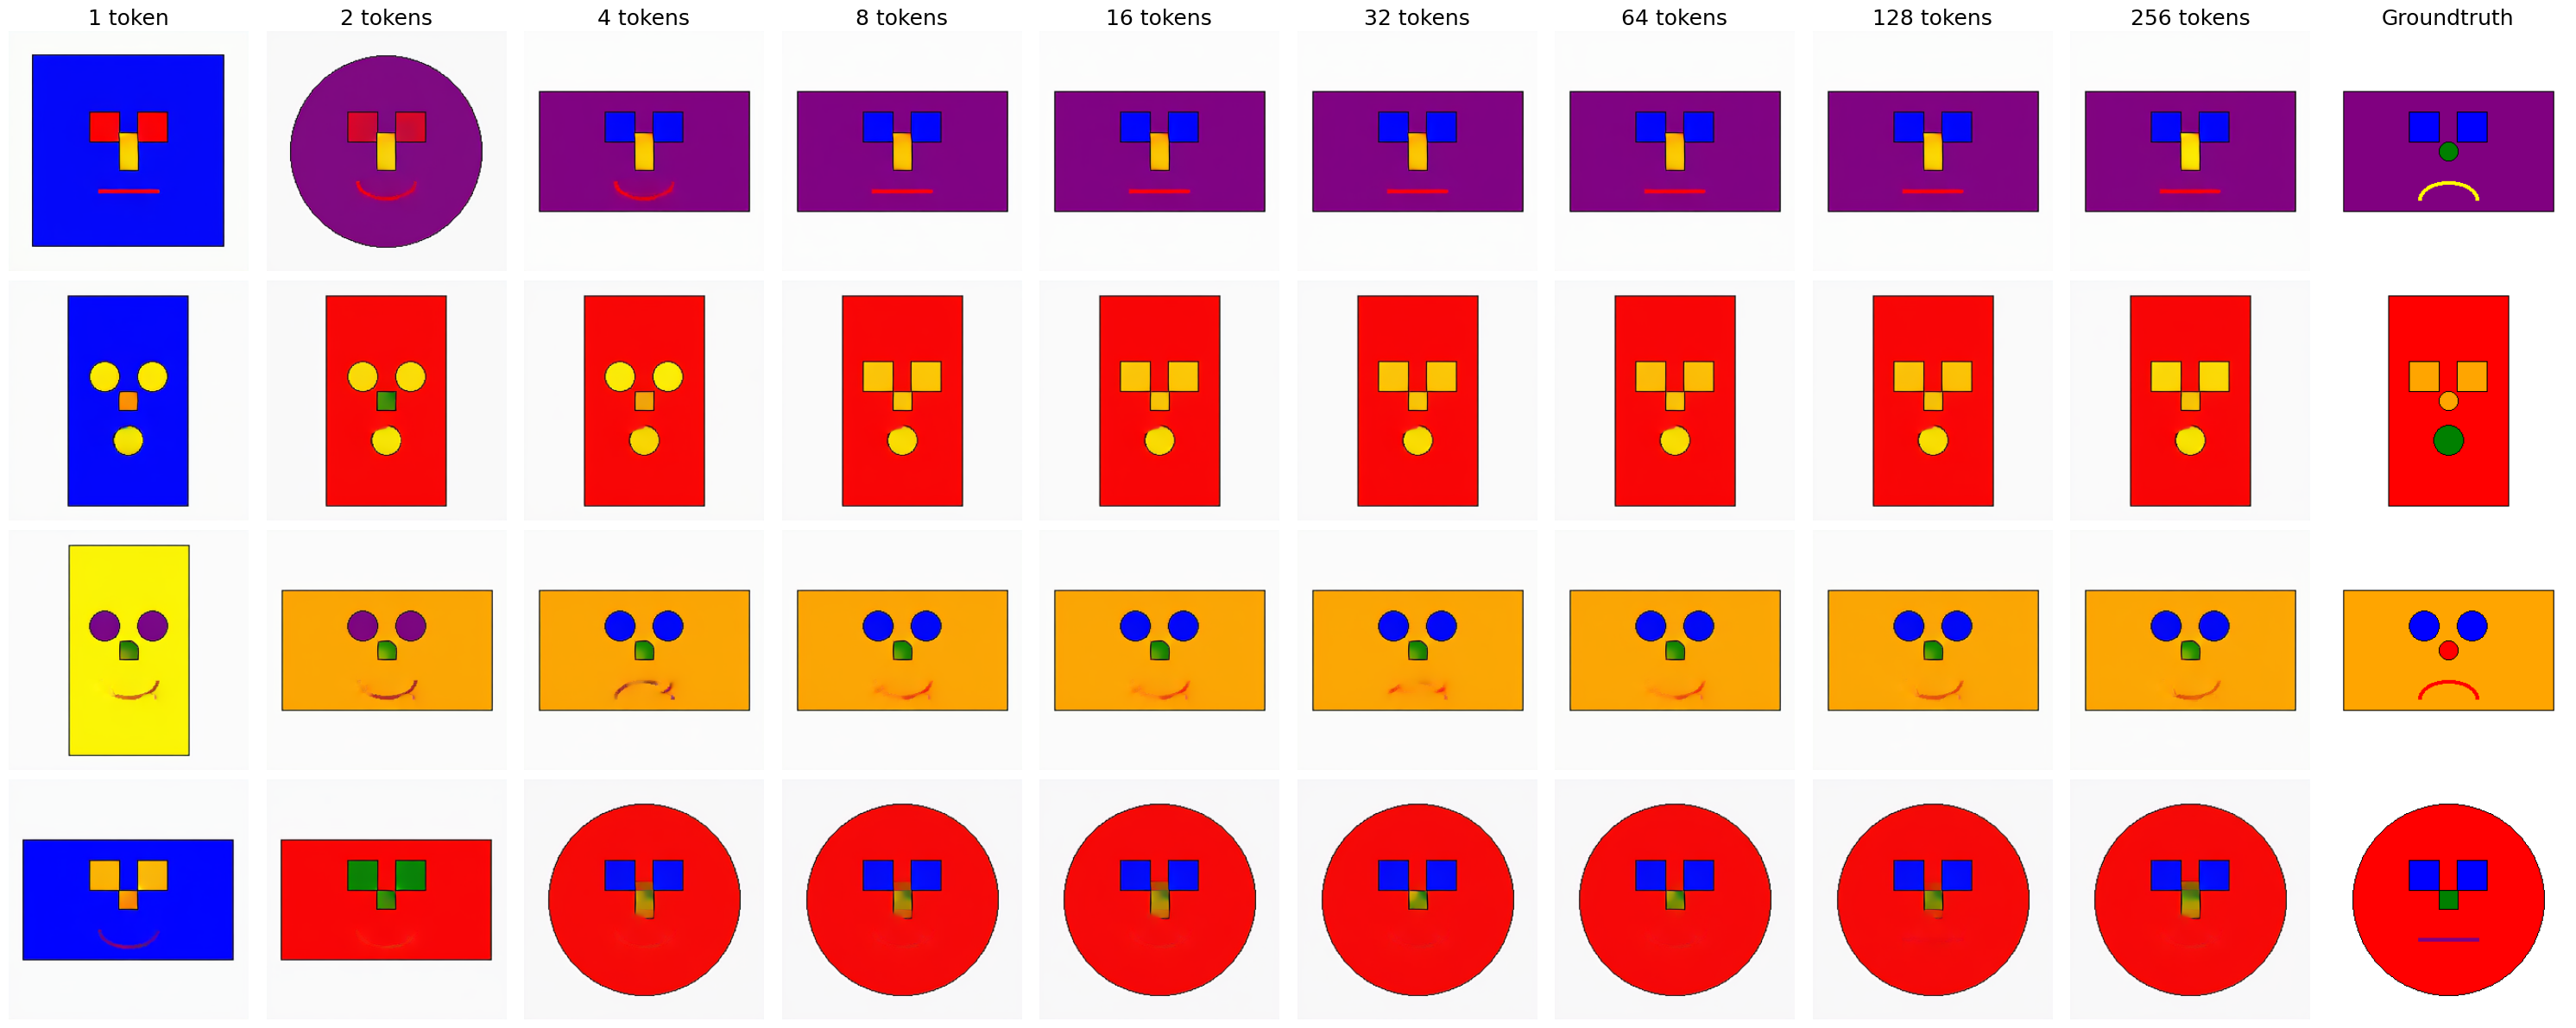

In [12]:
k_keep_list = [1, 2, 4, 8, 16, 32, 64, 128, 256]
plot_flexible_length_reconsts(imgs, k_keep_list, seed=0)

## 3 VAE-GAN inference

All FlexTok models operate on top of a VAE-GAN latent space, similar to the one of SDXL. Similar to SD3's findings, we found the 4-channel SDXL VAE-GAN compression to be too strong for subsequent use and decided to train our own VAE-GAN models with 4, 8, and 16 channels and a downsampling factor of 8. For all FlexTok models we used the 16-channel version.

In the following we show how to load our VAE-GAN models and autoencode the loaded images.

### 3.1 Helper functions

In [12]:
def vae_encode(imgs, vae_model):
    scaling_factor = vae_model.config['scaling_factor']
    return vae_model.encode(imgs).latent_dist.sample() * scaling_factor

def vae_decode(latents, vae_model):
    scaling_factor = vae_model.config['scaling_factor']
    return vae_model.decode(latents / scaling_factor).sample

def plot_vae_reconst(imgs, reconst_sdxl_c4, reconst_c4, reconst_c8, reconst_c16, figscale=3.0):
    ncols = 5 # SDXL ch4 | ch4 | ch8 | ch16 | GT
    nrows = imgs.shape[0]

    fig, axes = plt.subplots(nrows, ncols, figsize=(figscale*ncols, figscale*nrows))
    axes = [axes] if nrows == 1 else axes
    
    imgs_plot = denormalize(imgs)
    reconst_sdxl_c4_plot = denormalize(reconst_sdxl_c4).clamp(0,1)
    reconst_c4_plot = denormalize(reconst_c4).clamp(0,1)
    reconst_c8_plot = denormalize(reconst_c8).clamp(0,1)
    reconst_c16_plot = denormalize(reconst_c16).clamp(0,1)
    
    for img_idx in range(nrows):
        axes[img_idx][0].imshow(TF.to_pil_image(reconst_sdxl_c4_plot[img_idx]))
        axes[img_idx][1].imshow(TF.to_pil_image(reconst_c4_plot[img_idx]))
        axes[img_idx][2].imshow(TF.to_pil_image(reconst_c8_plot[img_idx]))
        axes[img_idx][3].imshow(TF.to_pil_image(reconst_c16_plot[img_idx]))
        axes[img_idx][4].imshow(TF.to_pil_image(imgs_plot[img_idx]))

        for ax in axes[img_idx]:
            ax.axis("off")

    axes[0][0].set_title('4-channel SDXL VAE')
    axes[0][1].set_title('4-channel FlexTok VAE')
    axes[0][2].set_title('8-channel FlexTok VAE')
    axes[0][3].set_title('16-channel FlexTok VAE')
    axes[0][4].set_title('GT')

    plt.tight_layout()
    plt.show()

### 3.2 Load VAE-GAN models

All VAE-GAN models use the same architecture as the SDXL VAE, but differ in the number of latent channels. They can be loaded from HuggingFace Hub using `diffusers.models.AutoencoderKL`. 

In [13]:
vae_c4  = AutoencoderKL.from_pretrained('EPFL-VILAB/flextok_vae_c4', low_cpu_mem_usage=False).to(device).eval()
vae_c8  = AutoencoderKL.from_pretrained('EPFL-VILAB/flextok_vae_c8', low_cpu_mem_usage=False).to(device).eval()
vae_c16 = AutoencoderKL.from_pretrained('EPFL-VILAB/flextok_vae_c16', low_cpu_mem_usage=False).to(device).eval()

/home/iyu/miniconda3/envs/flextok/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


We also load a baseline SDXL VAE for comparison:

In [14]:
vae_sdxl_c4 = AutoencoderKL.from_pretrained('stabilityai/sdxl-vae', low_cpu_mem_usage=False).to(device).eval()

### 3.3 Plot reconstructions

In the following, we show reconstructions from each VAE. The VAEs map images of size 256x256 pixels to a 4, 8, or 16 channel latent space of height and width 32x32.

In [15]:
reconst_c4  = vae_decode(vae_encode(imgs, vae_c4), vae_c4)
reconst_c8  = vae_decode(vae_encode(imgs, vae_c8), vae_c8)
reconst_c16 = vae_decode(vae_encode(imgs, vae_c16), vae_c16)

reconst_sdxl_c4  = vae_decode(vae_encode(imgs, vae_sdxl_c4), vae_sdxl_c4)

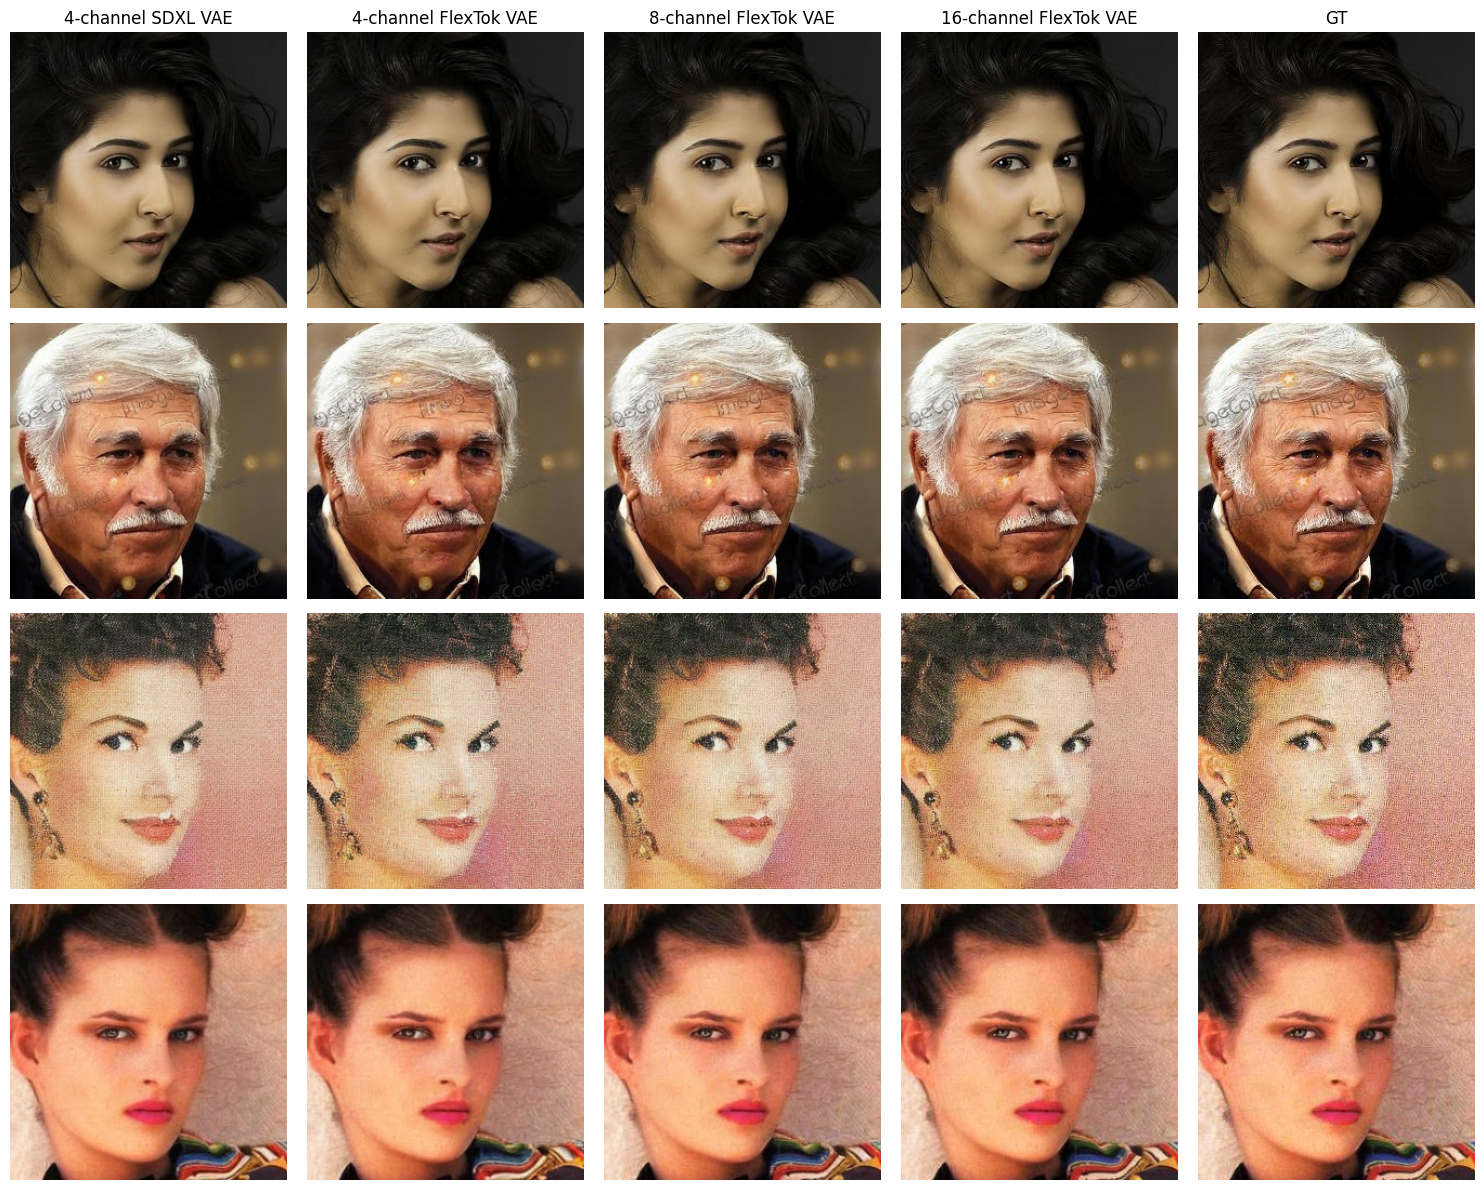

In [16]:
plot_vae_reconst(imgs, reconst_sdxl_c4, reconst_c4, reconst_c8, reconst_c16)